<a href="https://colab.research.google.com/github/Samu24042/CienciaDeDatos/blob/main/ProyectoFInal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [48]:
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import shapiro
from scipy import stats
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from sklearn.decomposition import PCA
import plotly.express as px

In [49]:

df = pd.read_csv('3min_resting.csv',sep = ';', skiprows=1)
df.sample(n=5)

,Fatigue,S1_MeanRR,S1_SDNN,S1_MinHR,S1_MaxHR,S1_RMSSD,S1_pNNxx,S1_HRVtriangularindex,S1_VLFpow_FFT_log,S1_LFpow_FFT_log,...,S1_TOTpow_FFT,S1_LF_HF_ratio_FFT,S1_SD1,S1_SD2,S1_SD2_SD1_ratio,S1_ApEn,S1_SampEn,S1_D2,S1_DFA1,S1_DFA2
21,0,691.395977,49.451710,76.655960,100.586756,42.270333,23.076923,11.863636,3.376768,7.373902,...,7.726564,2.476456,29.948325,63.111056,2.107332,1.048698,1.745360,3.996639,1.206387,0.292000
54,0,646.400935,36.130276,81.133928,110.392334,26.599005,4.693141,9.266667,4.332628,6.576868,...,7.049722,2.007429,18.843002,47.386307,2.514796,0.989695,1.513742,3.692558,1.204737,0.555007
31,0,851.285236,47.393782,63.584918,82.491689,37.401293,17.535545,14.133333,4.210866,7.193142,...,7.496261,3.298697,26.509675,61.696990,2.327339,0.877652,1.576814,3.974521,1.274998,0.271525
89,1,785.922777,83.635705,64.145876,88.969818,79.338444,33.480176,13.411765,6.368316,8.287562,...,8.936573,1.305194,56.225717,104.193768,1.853134,0.867919,1.034705,2.640466,1.085907,0.380988
46,0,749.102167,80.835363,63.950477,103.616921,65.745695,38.912134,18.461538,4.000418,7.825831,...,8.668059,0.769635,46.587406,104.424376,2.241472,0.880542,1.199660,3.522554,1.038249,0.192846


In [50]:
# --- INSPECCIÓN DE NULOS Y ELIMINACIÓN DE COLUMNAS ---

# isna().sum() nos muestra cuántos valores faltantes hay por cada columna
print("--- Valores nulos por columna ---")
print(df.isna().sum())

--- Valores nulos por columna ---
Fatigue                  0
S1_MeanRR                0
S1_SDNN                  0
S1_MinHR                 0
S1_MaxHR                 0
S1_RMSSD                 0
S1_pNNxx                 0
S1_HRVtriangularindex    0
S1_VLFpow_FFT_log        0
S1_LFpow_FFT_log         0
S1_HFpow_FFT_log         0
S1_TOTpow_FFT            0
S1_LF_HF_ratio_FFT       0
S1_SD1                   0
S1_SD2                   0
S1_SD2_SD1_ratio         0
S1_ApEn                  0
S1_SampEn                0
S1_D2                    0
S1_DFA1                  0
S1_DFA2                  0
dtype: int64


In [51]:
# 1. Separamos la etiqueta 'Fatigue' (y) de las variables del corazón (X)
features = X.columns.tolist()
X = df.drop(columns=['Fatigue'])
y = df['Fatigue']

# 2. Inicializamos el estandarizador (StandardScaler)
scaler = StandardScaler()

# 3. Ajustamos y transformamos la matriz X
X_scaled = scaler.fit_transform(X)

print("--- REPORTE DE ESTANDARIZACIÓN ---")
print(f"-> Matriz original X: {X.shape[0]} filas y {X.shape[1]} columnas.")
print(f"-> Matriz X_escalado lista: {X_escalado.shape[0]} filas y {X_escalado.shape[1]} variables transformadas.")
print(f"-> Vector y (etiquetas): {y.shape[0]} filas.")

--- REPORTE DE ESTANDARIZACIÓN ---
-> Matriz original X: 164 filas y 20 columnas.
-> Matriz X_escalado lista: 164 filas y 20 variables transformadas.
-> Vector y (etiquetas): 164 filas.


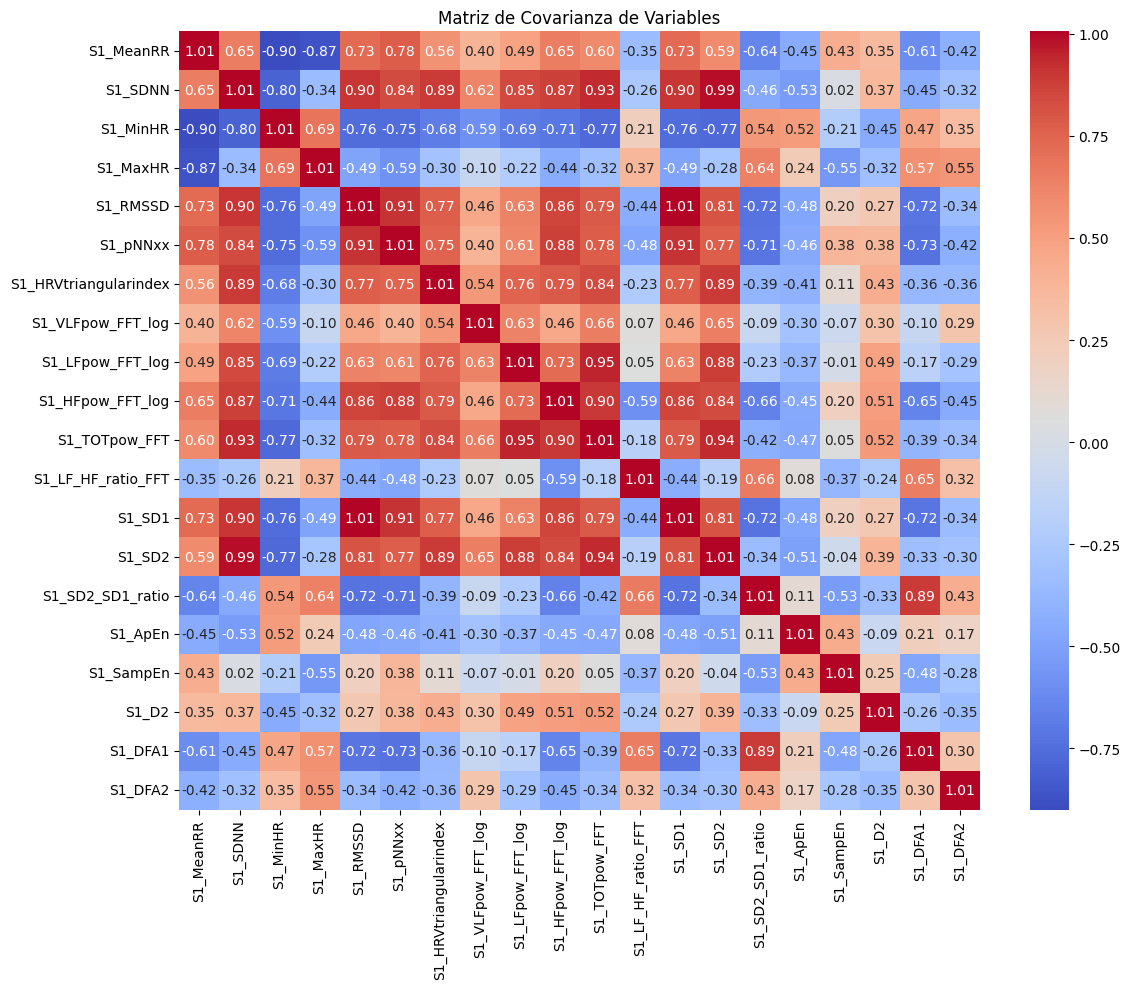

In [52]:
# =====================================================================
# 2. Calcular la matriz de covarianza y graficar mapa de calor
# =====================================================================
# Calcular la matriz de covarianza sobre los datos estandarizados
cov_matrix = np.cov(X_scaled, rowvar=False)
# print("Matriz de correlación:",cov_matrix)

# Graficar la matriz de covarianza utilizando seaborn
plt.figure(figsize=(12, 10))
sns.heatmap(cov_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            xticklabels=features, yticklabels=features)
plt.title('Matriz de Covarianza de Variables')
plt.tight_layout()
plt.show()

In [57]:
# =====================================================================
# PASO 3: CÁLCULO DEL PCA (REDUCCIÓN A 3 COMPONENTES)
# =====================================================================
# 1. Inicializamos el PCA para 3 componentes
pca = PCA(n_components=3, random_state=42)

# 2. Ajustamos y transformamos la matriz de datos escalados
X_pca = pca.fit_transform(X_scaled) # Asegúrate de que se llame igual a tu variable escalada

# 3. Creamos el nuevo DataFrame con los componentes y la etiqueta de Fatiga
df_pca = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2', 'PC3'])
df_pca['Fatigue'] = y.values

# 4. Mostramos el reporte de varianza explicada
varianza_explicada = pca.explained_variance_ratio_
print("--- REPORTE DE VARIANZA EXPLICADA POR EL PCA ---")
print(f"Componente Principal 1 (PC1): {varianza_explicada[0]*100:.2f}% de la información.")
print(f"Componente Principal 2 (PC2): {varianza_explicada[1]*100:.2f}% de la información.")
print(f"Componente Principal 3 (PC3): {varianza_explicada[2]*100:.2f}% de la información.")
print(f"TOTAL DE INFORMACIÓN RETENIDA: {sum(varianza_explicada)*100:.2f}%\n")

print("Muestra aleatoria del nuevo dataset reducido:")
display(df_pca.sample(n=5, random_state=42))

--- REPORTE DE VARIANZA EXPLICADA POR EL PCA ---
Componente Principal 1 (PC1): 55.78% de la información.
Componente Principal 2 (PC2): 15.52% de la información.
Componente Principal 3 (PC3): 6.55% de la información.
TOTAL DE INFORMACIÓN RETENIDA: 77.86%

Muestra aleatoria del nuevo dataset reducido:


,PC1,PC2,PC3,Fatigue
135,4.568060,-1.484050,0.453066,1
115,-0.902485,0.667214,-0.051636,1
131,2.567540,-2.630345,-0.789504,1
55,-5.912010,0.064088,-0.534605,0
95,-2.428856,0.933850,-2.230974,1


In [54]:
# =====================================================================
# PASO 4: GRAFICACIÓN INTERACTIVA EN 3D
# =====================================================================

# Convertimos la columna 'Fatigue' a texto temporalmente para que la gráfica asigne colores discretos
df_grafica = df_pca.copy()
df_grafica['Fatigue'] = df_grafica['Fatigue'].map({0: 'No Fatigado (Baseline)', 1: 'Fatigado (Post-Tarea)'})

# Creamos el mapa de dispersión en 3D
fig = px.scatter_3d(
    df_grafica,
    x='PC1',
    y='PC2',
    z='PC3',
    color='Fatigue',
    color_discrete_map={'No Fatigado (Baseline)': 'royalblue', 'Fatigado (Post-Tarea)': 'crimson'},
    title='Análisis de Componentes Principales (PCA) de 3D - Datos de HRV',
    labels={'PC1': 'Componente 1', 'PC2': 'Componente 2', 'PC3': 'Componente 3'},
    opacity=0.8
)

# Ajustamos el tamaño del gráfico
fig.update_layout(margin=dict(l=0, r=0, b=0, t=40), width=800, height=600)

# Mostramos la gráfica interactiva
fig.show()

         REPORTE DE RENDIMIENTO DEL CLASIFICADOR        
Exactitud Global (Accuracy): 72.73%

Métricas detalladas por clase:
                 precision    recall  f1-score   support

No Fatigado (0)       0.75      0.71      0.73        17
   Fatigado (1)       0.71      0.75      0.73        16

       accuracy                           0.73        33
      macro avg       0.73      0.73      0.73        33
   weighted avg       0.73      0.73      0.73        33



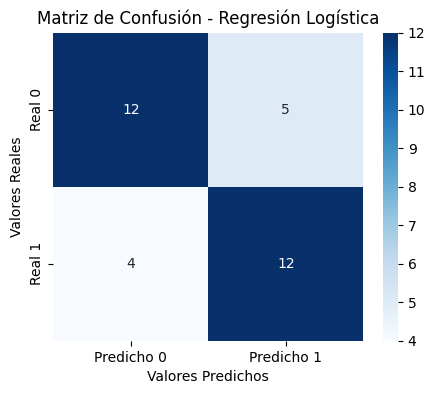

In [55]:
# =====================================================================
# PASO 5: ENTRENAMIENTO Y EVALUACIÓN DE LA REGRESIÓN LOGÍSTICA
# =====================================================================

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Definimos las variables de entrada (los 3 componentes) y la variable objetivo (Fatiga)
X_modelado = df_pca[['PC1', 'PC2', 'PC3']]
y_modelado = df_pca['Fatigue']

# 2. Dividimos en Entrenamiento (80%) y Prueba (20%) de forma estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X_modelado, y_modelado, test_size=0.20, random_state=42, stratify=y_modelado
)

# 3. Inicializamos y entrenamos el modelo de Regresión Logística
clasificador = LogisticRegression(random_state=42)
clasificador.fit(X_train, y_train)

# 4. Realizamos las predicciones sobre el conjunto de prueba
y_pred = clasificador.predict(X_test)

# 5. REPORTE DE MÉTRICAS GENERALES
print("=======================================================")
print("         REPORTE DE RENDIMIENTO DEL CLASIFICADOR        ")
print("=======================================================")
exactitud = accuracy_score(y_test, y_pred)
print(f"Exactitud Global (Accuracy): {exactitud*100:.2f}%\n")

print("Métricas detalladas por clase:")
print(classification_report(y_test, y_pred, target_names=['No Fatigado (0)', 'Fatigado (1)']))

# 6. MATRIZ DE CONFUSIÓN (Visualización gráfica)
matriz = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicho 0', 'Predicho 1'],
            yticklabels=['Real 0', 'Real 1'])
plt.title('Matriz de Confusión - Regresión Logística')
plt.ylabel('Valores Reales')
plt.xlabel('Valores Predichos')
plt.show()

In [58]:
# =====================================================================
# COMPARATIVA DE CLASIFICADORES AVANZADOS (NO LINEALES)
# =====================================================================

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

print("=======================================================")
print("      COMPARATIVA DE RENDIMIENTO DE CLASIFICADORES     ")
print("=======================================================\n")

# 1. Traemos la Exactitud de la Regresión Logística que ya tenías (como base)
# (Asumiendo que tu modelo anterior se llama 'clasificador')
acc_logistica = accuracy_score(y_test, y_pred)
print(f"1. Regresión Logística (Lineal):     {acc_logistica*100:.2f}%")

# 2. Entrenamos Support Vector Machine (SVM) con Kernel RBF
modelo_svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
modelo_svm.fit(X_train, y_train)
y_pred_svm = modelo_svm.predict(X_test)
acc_svm = accuracy_score(y_test, y_pred_svm)
print(f"2. Support Vector Machine (RBF):    {acc_svm*100:.2f}%")

# 3. Entrenamos Random Forest Classifier
modelo_rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
modelo_rf.fit(X_train, y_train)
y_pred_rf = modelo_rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"3. Random Forest (No Lineal):       {acc_rf*100:.2f}%")

print("\n-------------------------------------------------------")
print("Nota: El modelo con mayor porcentaje es el candidato")
print("definitivo para el sistema de detección de fatiga.")

      COMPARATIVA DE RENDIMIENTO DE CLASIFICADORES     

1. Regresión Logística (Lineal):     72.73%
2. Support Vector Machine (RBF):    66.67%
3. Random Forest (No Lineal):       69.70%

-------------------------------------------------------
Nota: El modelo con mayor porcentaje es el candidato
definitivo para el sistema de detección de fatiga.


-> Nueva Exactitud de SVM Optimizado: 75.76%
     METRICAS DETALLADAS - SVM KERNEL RBF OPTIMIZADO   
Exactitud Obtenida (Accuracy): 75.76%

                 precision    recall  f1-score   support

No Fatigado (0)       0.80      0.71      0.75        17
   Fatigado (1)       0.72      0.81      0.76        16

       accuracy                           0.76        33
      macro avg       0.76      0.76      0.76        33
   weighted avg       0.76      0.76      0.76        33



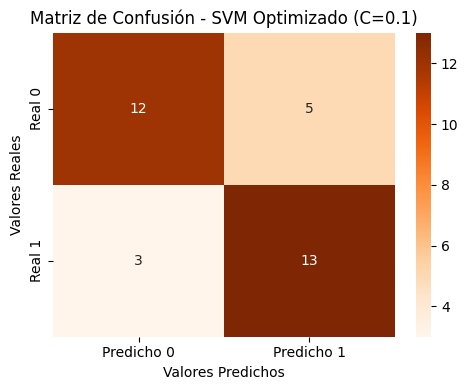

In [64]:
# =====================================================================
# TUNING DE SUPPORT VECTOR MACHINE (SUAVIZADO DE FRONTERA)
# =====================================================================

# Reducimos 'C' para suavizar la frontera curva y ajustamos 'gamma'
modelo_svm_opt = SVC(
    kernel='rbf',
    C=0.1,             # Penalización suave: prefiere una curva tersa aunque falle algunos datos de entrenamiento
    gamma='scale',     # Ajuste automático del radio de influencia de los puntos
    random_state=42
)

modelo_svm_opt.fit(X_train, y_train)
y_pred_svm_opt = modelo_svm_opt.predict(X_test)
acc_svm_opt = accuracy_score(y_test, y_pred_svm_opt)

print(f"-> Nueva Exactitud de SVM Optimizado: {acc_svm_opt*100:.2f}%")

# =====================================================================
# MATRIZ DE CONFUSIÓN Y REPORTE PARA SVM OPTIMIZADO
# =====================================================================

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculamos la matriz de confusión con las predicciones del modelo optimizado
matriz_svm = confusion_matrix(y_test, y_pred_svm_opt)

# 2. Imprimimos el reporte detallado en texto (Precision, Recall, F1-Score)
print("=======================================================")
print("     METRICAS DETALLADAS - SVM KERNEL RBF OPTIMIZADO   ")
print("=======================================================")
print(f"Exactitud Obtenida (Accuracy): {acc_svm_opt*100:.2f}%\n")
print(classification_report(y_test, y_pred_svm_opt, target_names=['No Fatigado (0)', 'Fatigado (1)']))

# 3. Graficamos la Matriz de Confusión de forma visual
plt.figure(figsize=(5, 4))
sns.heatmap(matriz_svm, annot=True, fmt='d', cmap='Oranges', # Usamos color naranja para diferenciarlo
            xticklabels=['Predicho 0', 'Predicho 1'],
            yticklabels=['Real 0', 'Real 1'])

plt.title('Matriz de Confusión - SVM Optimizado (C=0.1)')
plt.ylabel('Valores Reales')
plt.xlabel('Valores Predichos')
plt.tight_layout()
plt.show()